In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# B6 (partie 2) — Auto-encodeur & détection d'anomalies

Reprend les jeux prétraités en [partie 1](b6_deep_learning_donnees.md) (`screw/*.bin.gz`) pour concevoir,
entraîner et évaluer un auto-encodeur convolutionnel de détection d'anomalies.

In [7]:
import gzip
from pathlib import Path

import numpy as np

DATA_DIR = Path('screw')
IMG_SIZE = 128


def load_bin_gz(path, img_size=IMG_SIZE):
    with gzip.open(path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype='float32')
    return data.reshape(-1, img_size, img_size, 1)


X_train_norm = load_bin_gz(DATA_DIR / 'train_norm.bin.gz')
test_good_norm = load_bin_gz(DATA_DIR / 'test_good_norm.bin.gz')
test_defects_norm_stacked = load_bin_gz(DATA_DIR / 'test_defects_norm.bin.gz')

print('Train (normé)  :', X_train_norm.shape, X_train_norm.dtype)
print('Test saines    :', test_good_norm.shape)
print('Test défauts   :', test_defects_norm_stacked.shape)

Train (normé)  : (256, 128, 128, 1) float32
Test saines    : (41, 128, 128, 1)
Test défauts   : (119, 128, 128, 1)


Conception de l'auto-encodeur

In [8]:
from tensorflow import keras
from tensorflow.keras import layers

INPUT_SHAPE = X_train_norm.shape[1:]  # (128, 128, 1)

inputs = keras.Input(shape=INPUT_SHAPE, name='image')

# Encodeur : 3 convolutions stridées, le nombre de filtres se resserre pour forcer un vrai goulot
x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inputs)  # 64x64x32
x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)       # 32x32x64
latent = layers.Conv2D(8, 3, strides=2, padding='same', activation='relu')(x)   # 16x16x8 (goulot)

# Décodeur : 3 déconvolutions symétriques, sortie sigmoid dans [0, 1].
# Noyau=4 (multiple du stride=2) plutôt que 3, pour éviter l'artefact de damier
# ("checkerboard") typique des Conv2DTranspose quand noyau et stride ne s'accordent pas.
x = layers.Conv2DTranspose(64, 4, strides=2, padding='same', activation='relu')(latent)  # 32x32x64
x = layers.Conv2DTranspose(32, 4, strides=2, padding='same', activation='relu')(x)        # 64x64x32
outputs = layers.Conv2DTranspose(1, 4, strides=2, padding='same', activation='sigmoid')(x)  # 128x128x1

autoencoder = keras.Model(inputs, outputs, name='autoencodeur_screw')
autoencoder.summary()

Model: "autoencodeur_screw"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 8)      │         4,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 32, 32, 64)     │         8,256 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 64, 64, 32)     │        32,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 128, 128, 1)    │           513 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,001 (253.91 KB)

 Trainable params: 65,001 (253.91 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
input_size = np.prod(INPUT_SHAPE)
latent_size = np.prod(latent.shape[1:])
ratio = latent_size / input_size

print(f'Taille entrée       : {input_size} valeurs {INPUT_SHAPE}')
print(f'Taille goulot       : {latent_size} valeurs {tuple(latent.shape[1:])}')
print(f'Ratio goulot/entrée : {ratio:.3f}  (compression ×{1 / ratio:.1f})')

Taille entrée       : 16384 valeurs (128, 128, 1)
Taille goulot       : 2048 valeurs (16, 16, 8)
Ratio goulot/entrée : 0.125  (compression ×8.0)


**Commentaire.** Le modèle compte **65 001 paramètres** (tous entraînables), essentiellement dans les
6 couches de convolution/déconvolution — pas de couche dense, donc pas d'explosion de paramètres malgré
la taille des images (128×128). Le décodeur utilise un noyau de taille **4** (multiple du stride 2, au lieu
de 3) pour éviter l'artefact de damier ("checkerboard") typique des `Conv2DTranspose`, ce qui explique le
léger surplus de paramètres par rapport à un noyau 3×3.

Le **goulot d'étranglement** est la sortie de la 3ᵉ convolution : `16×16×8 = 2048` valeurs, contre
`128×128×1 = 16384` valeurs en entrée → **ratio de 0.125** (compression ×8). Ce ratio est volontairement
resserré via le nombre de filtres (32 → 64 → **8**, et non croissant jusqu'au bout) : avec un goulot proche
de la taille d'entrée, le modèle pourrait apprendre une quasi-identité et reconstruire aussi bien les
défauts que les pièces saines, ce qui ferait disparaître le signal d'anomalie recherché.

# Étape 2

Entrainement du model, on entraine (enregistrement via MLFlow) un model

In [ ]:
import mlflow
import tensorflow as tf

mlflow.set_tracking_uri('sqlite:///../mlflow.db')
mlflow.set_experiment('b6_deep_learning_autoencodeur_2')


def ssim_loss(y_true, y_pred):
    return 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))


EPOCHS = 80 # 1 EPOCH => toutes les images sont passées et la backprop (rétropropagation) est passée
BATCH_SIZE = 16
PATIENCE = 4
MIN_DELTA = 1e-3

autoencoder.compile(optimizer='adam', loss=ssim_loss)

# Arrête l'entraînement si val_loss ne s'améliore plus d'au moins MIN_DELTA pendant PATIENCE époques.
# Sans min_delta, un nouveau record de +0.0001 compte comme une "amélioration" et remet le compteur
# à zéro indéfiniment (ce qu'on observe ici : val_loss grappille des micro-records en permanence).
# restore_best_weights ramène le modèle à l'époque où val_loss était la meilleure, pas la dernière.
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    restore_best_weights=True,
)

with mlflow.start_run(run_name='autoencoder_conv_screw_ssim'):
    mlflow.log_params({
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'optimizer': 'adam',
        'loss': 'ssim',
        'decoder_kernel_size': 4,
        'early_stopping_patience': PATIENCE,
        'early_stopping_min_delta': MIN_DELTA,
        'latent_shape': str(tuple(latent.shape[1:])),
        'compression_ratio': round(float(ratio), 4),
    })

    history = autoencoder.fit(
        X_train_norm, X_train_norm,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        callbacks=[early_stopping],
        verbose=2,
    )

    mlflow.log_param('stopped_epoch', early_stopping.stopped_epoch or len(history.history['loss']))
    for epoch, (loss, val_loss) in enumerate(zip(history.history['loss'], history.history['val_loss'])):
        mlflow.log_metrics({'loss': loss, 'val_loss': val_loss}, step=epoch)

Epoch 1/150
13/13 - 5s - 397ms/step - loss: 0.2925 - val_loss: 0.2895
Epoch 2/150
13/13 - 4s - 290ms/step - loss: 0.2675 - val_loss: 0.2363
Epoch 3/150
13/13 - 4s - 303ms/step - loss: 0.2190 - val_loss: 0.1971
Epoch 4/150
13/13 - 4s - 308ms/step - loss: 0.1857 - val_loss: 0.1708
Epoch 5/150
13/13 - 4s - 302ms/step - loss: 0.1563 - val_loss: 0.1437
Epoch 6/150
13/13 - 4s - 327ms/step - loss: 0.1408 - val_loss: 0.1366
Epoch 7/150
13/13 - 4s - 304ms/step - loss: 0.1351 - val_loss: 0.1316
Epoch 8/150
13/13 - 5s - 351ms/step - loss: 0.1302 - val_loss: 0.1268
Epoch 9/150
13/13 - 4s - 346ms/step - loss: 0.1238 - val_loss: 0.1177
Epoch 10/150
13/13 - 5s - 362ms/step - loss: 0.1138 - val_loss: 0.1062
Epoch 11/150
13/13 - 5s - 381ms/step - loss: 0.1048 - val_loss: 0.0999
Epoch 12/150
13/13 - 4s - 344ms/step - loss: 0.0974 - val_loss: 0.0910
Epoch 13/150
13/13 - 4s - 334ms/step - loss: 0.0895 - val_loss: 0.0840
Epoch 14/150
13/13 - 5s - 373ms/step - loss: 0.0831 - val_loss: 0.0783
Epoch 15/150
13

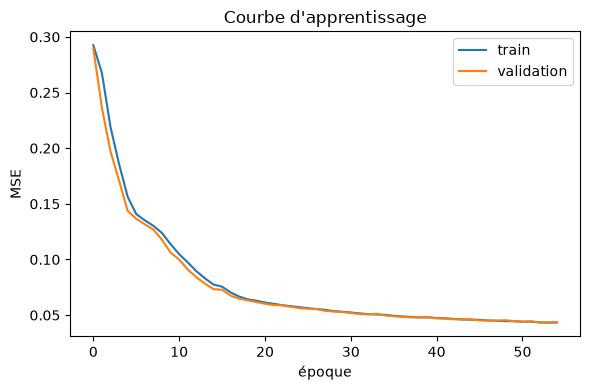

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel('époque')
plt.ylabel('MSE')
plt.title("Courbe d'apprentissage")
plt.legend()
plt.tight_layout()
plt.show()

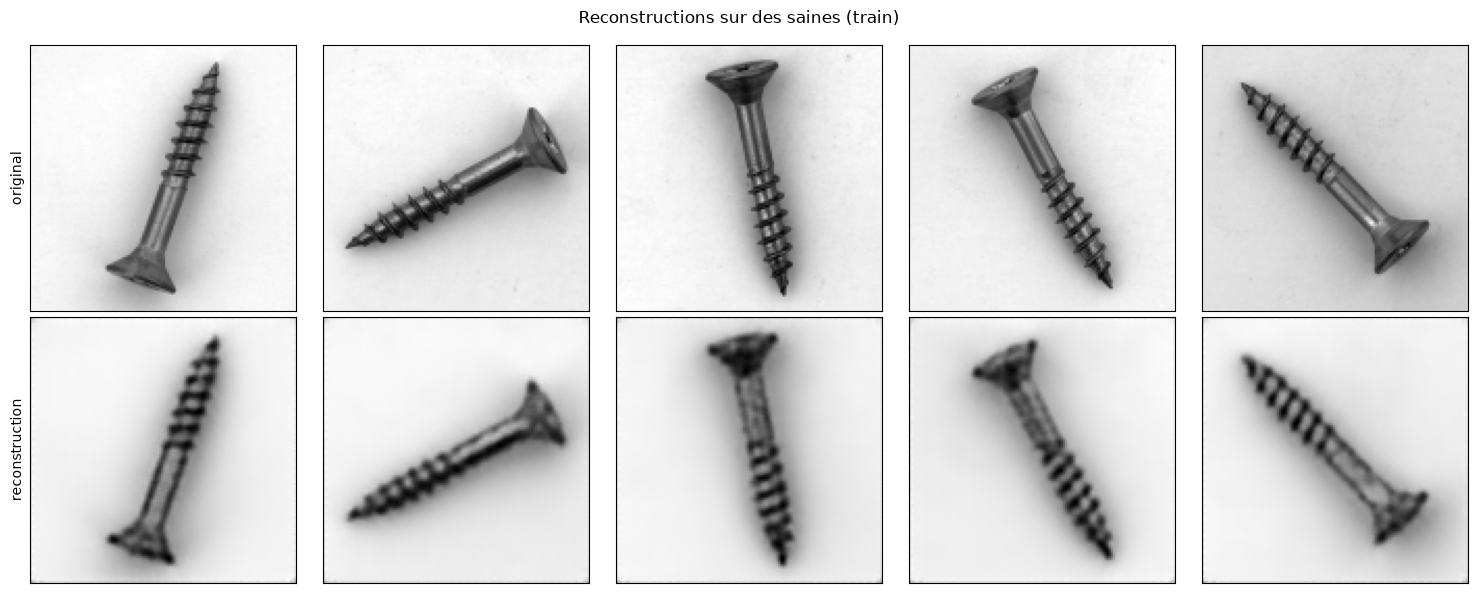

In [12]:
n_examples = 5
reconstructions = autoencoder.predict(X_train_norm[:n_examples], verbose=0)

fig, axes = plt.subplots(2, n_examples, figsize=(3 * n_examples, 6))
for i in range(n_examples):
    axes[0, i].imshow(X_train_norm[i, ..., 0], cmap='gray')
    axes[1, i].imshow(reconstructions[i, ..., 0], cmap='gray')

axes[0, 0].set_ylabel('original')
axes[1, 0].set_ylabel('reconstruction')
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Reconstructions sur des saines (train)')
fig.tight_layout()
plt.show()

# Étape 3 — Score d'anomalie & seuil

In [13]:
VALIDATION_SPLIT = 0.2  # doit correspondre au validation_split utilisé dans le fit()

# Keras prend les derniers `validation_split` % de X_train_norm comme validation (avant shuffle) :
# on retrouve ce même sous-ensemble pour évaluer l'erreur de reconstruction.
split_at = int(len(X_train_norm) * (1 - VALIDATION_SPLIT))
X_val_norm = X_train_norm[split_at:]

reconstructions_val = autoencoder.predict(X_val_norm, verbose=0)
errors_val = np.mean((X_val_norm - reconstructions_val) ** 2, axis=(1, 2, 3))

print('Erreur de reconstruction (saines, validation) :', errors_val.shape)
print(f'  moyenne = {errors_val.mean():.5f}, écart-type = {errors_val.std():.5f}')

Erreur de reconstruction (saines, validation) : (52,)
  moyenne = 0.00050, écart-type = 0.00010


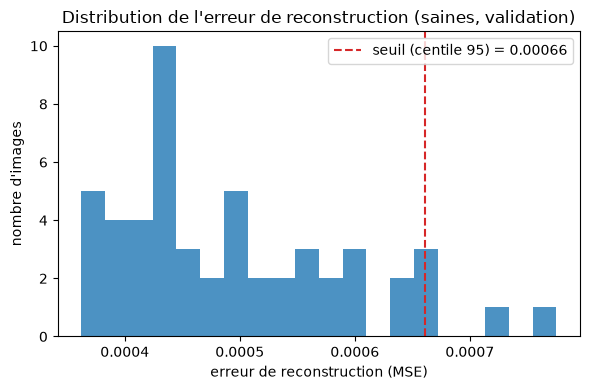

In [15]:
threshold_p95 = np.percentile(errors_val, 95)

plt.figure(figsize=(6, 4))
plt.hist(errors_val, bins=20, color='tab:blue', alpha=0.8)
plt.axvline(threshold_p95, color='tab:red', linestyle='--', label=f'seuil (centile 95) = {threshold_p95:.5f}')
plt.xlabel('erreur de reconstruction (MSE)')
plt.ylabel("nombre d'images")
plt.title("Distribution de l'erreur de reconstruction (saines, validation)")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
reconstructions_test_good = autoencoder.predict(test_good_norm, verbose=0)
errors_test_good = np.mean((test_good_norm - reconstructions_test_good) ** 2, axis=(1, 2, 3))

print('Erreur de reconstruction (saines, test) :', errors_test_good.shape)
print(f'  moyenne = {errors_test_good.mean():.5f}, écart-type = {errors_test_good.std():.5f}')

Erreur de reconstruction (saines, test) : (41,)
  moyenne = 0.00039, écart-type = 0.00004


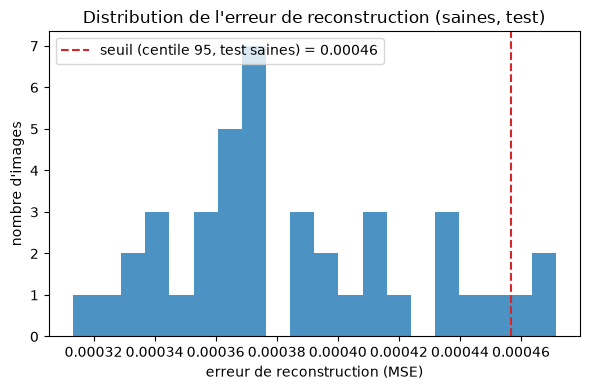

In [21]:
threshold_p95_test = np.percentile(errors_test_good, 95)

plt.figure(figsize=(6, 4))
plt.hist(errors_test_good, bins=20, color='tab:blue', alpha=0.8)
plt.axvline(threshold_p95_test, color='tab:red', linestyle='--', label=f'seuil (centile 95, test saines) = {threshold_p95_test:.5f}')
plt.xlabel('erreur de reconstruction (MSE)')
plt.ylabel("nombre d'images")
plt.title("Distribution de l'erreur de reconstruction (saines, test)")
plt.legend()
plt.tight_layout()
plt.show()

Courbes saines de validation et de tests sensiblement identiques 

In [22]:
reconstructions_test_defects = autoencoder.predict(test_defects_norm_stacked, verbose=0)
errors_test_defects = np.mean((test_defects_norm_stacked - reconstructions_test_defects) ** 2, axis=(1, 2, 3))

print('Erreur de reconstruction (défauts, test) :', errors_test_defects.shape)
print(f'  moyenne = {errors_test_defects.mean():.5f}, écart-type = {errors_test_defects.std():.5f}')

Erreur de reconstruction (défauts, test) : (119,)
  moyenne = 0.00053, écart-type = 0.00007


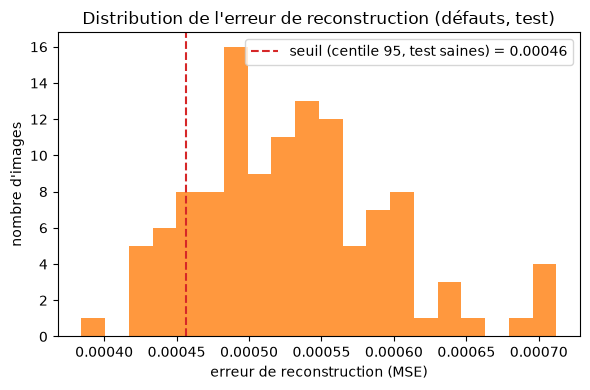

In [23]:
plt.figure(figsize=(6, 4))
plt.hist(errors_test_defects, bins=20, color='tab:orange', alpha=0.8)
plt.axvline(threshold_p95_test, color='tab:red', linestyle='--', label=f'seuil (centile 95, test saines) = {threshold_p95_test:.5f}')
plt.xlabel('erreur de reconstruction (MSE)')
plt.ylabel("nombre d'images")
plt.title("Distribution de l'erreur de reconstruction (défauts, test)")
plt.legend()
plt.tight_layout()
plt.show()

# Étape 4 — Heatmaps & évaluation

On prend trois images du set test_defects_norm_stacked et on affiche :
original | reconstruction | heatmap | masque ground-truth

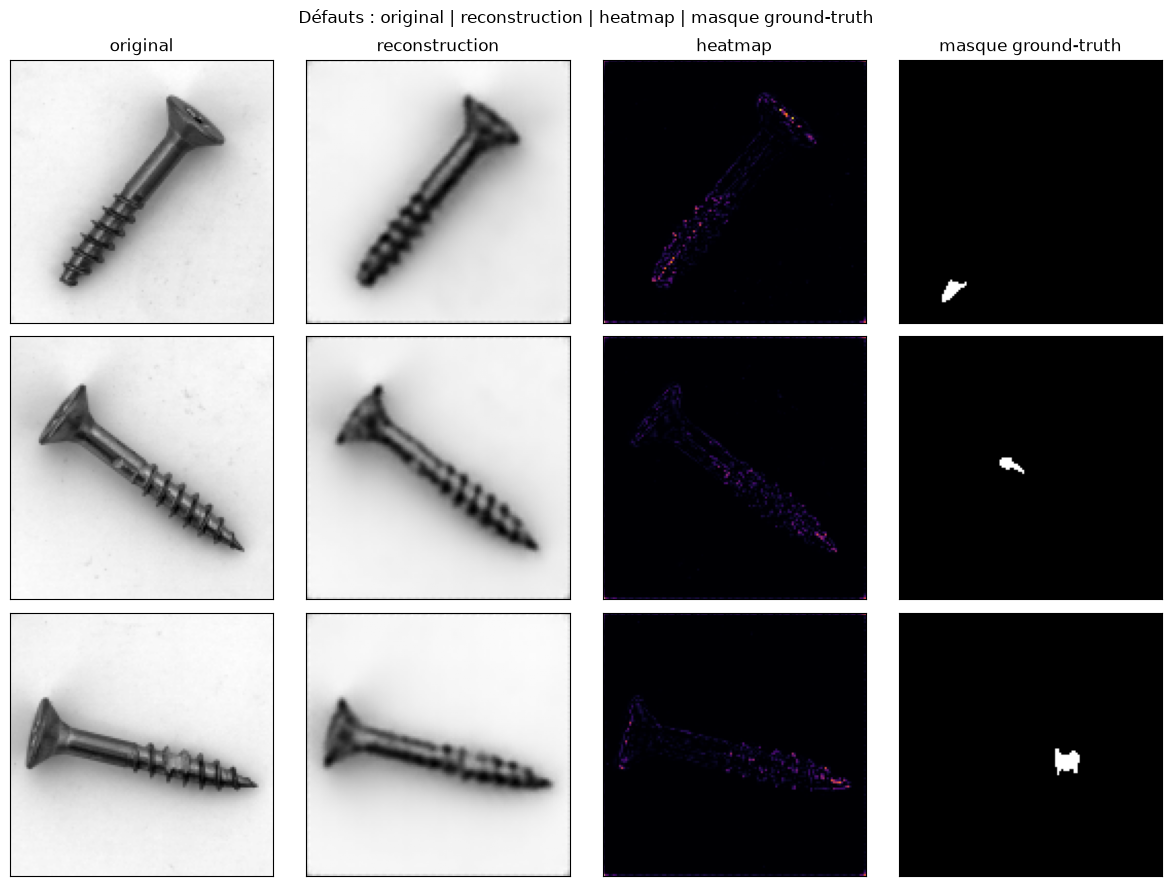

In [24]:
import cv2

TEST_DIR = DATA_DIR / 'test'
GT_DIR = DATA_DIR / 'ground_truth'
defect_types = sorted(p.name for p in TEST_DIR.iterdir() if p.is_dir() and p.name != 'good')

# Reconstitue, pour chaque indice de test_defects_norm_stacked, le chemin du masque correspondant
# (même ordre de concaténation qu'en partie 1 : catégories triées, fichiers triés dans chaque catégorie).
mask_paths = []
for defect in defect_types:
    img_paths = sorted((TEST_DIR / defect).glob('*.png'))
    mask_paths += [GT_DIR / defect / f'{p.stem}_mask.png' for p in img_paths]


def load_mask(path, size=IMG_SIZE):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    return cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)


indices = [0, 50, 100]  # trois défauts de catégories différentes (déjà en mémoire, pas de recalcul)

fig, axes = plt.subplots(len(indices), 4, figsize=(12, 3 * len(indices)))
col_titles = ['original', 'reconstruction', 'heatmap', 'masque ground-truth']

for row, idx in enumerate(indices):
    original = test_defects_norm_stacked[idx, ..., 0]
    reconstruction = reconstructions_test_defects[idx, ..., 0]
    heatmap = (original - reconstruction) ** 2
    mask = load_mask(mask_paths[idx])

    axes[row, 0].imshow(original, cmap='gray')
    axes[row, 1].imshow(reconstruction, cmap='gray')
    axes[row, 2].imshow(heatmap, cmap='inferno')
    axes[row, 3].imshow(mask, cmap='gray')

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title)
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Défauts : original | reconstruction | heatmap | masque ground-truth')
fig.tight_layout()
plt.show()

# Évalution AUC-ROC

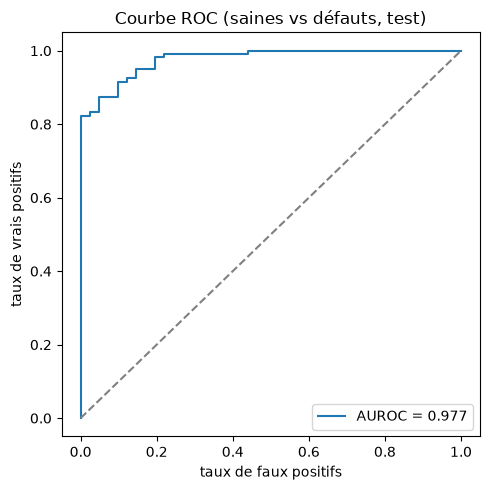

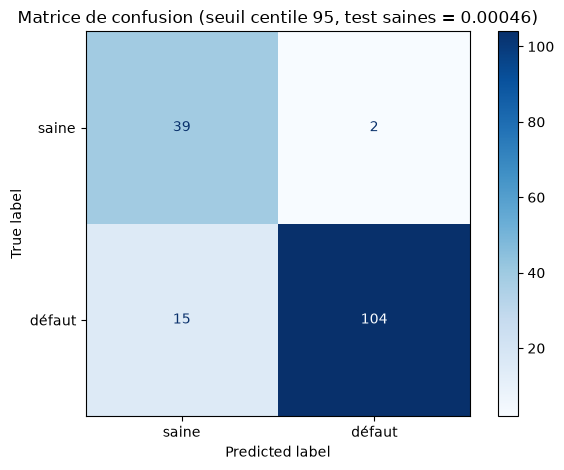

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay, auc, confusion_matrix, roc_curve

y_true = np.concatenate([np.zeros(len(errors_test_good)), np.ones(len(errors_test_defects))])
y_score = np.concatenate([errors_test_good, errors_test_defects])

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'AUROC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('taux de faux positifs')
plt.ylabel('taux de vrais positifs')
plt.title('Courbe ROC (saines vs défauts, test)')
plt.legend()
plt.tight_layout()
plt.show()

y_pred = (y_score > threshold_p95_test).astype(int)
cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(cm, display_labels=['saine', 'défaut']).plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil centile 95, test saines = {threshold_p95_test:.5f})')
plt.tight_layout()
plt.show()

15 prédites saines alors qu'avec défaut (mais 104 défaut trouvés correctement)
2 prédites en défauts alors que saines (mais 39 saines trouvés correctement)

# Test visuel pour comprendre

On prend les deux faux-positifs en défaut (alors que saine), et deux faux-positifs prédites saines sur les 15 (alors qu'en défaut)


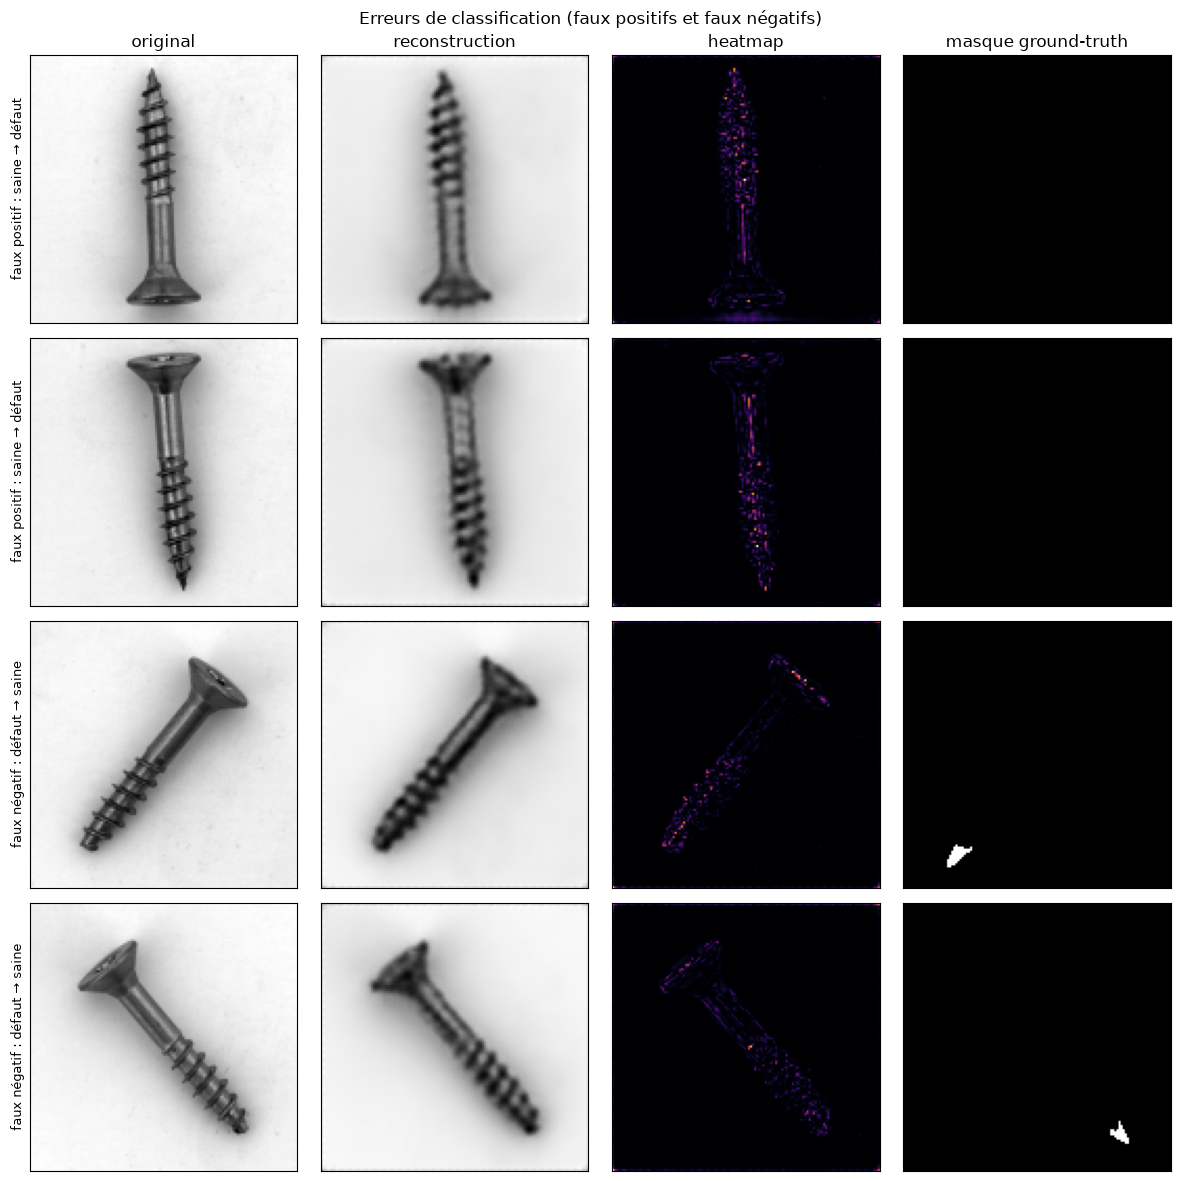

In [29]:
n_good = len(errors_test_good)  # offset : y_true/y_pred = [saines de test, puis défauts de test]

fp_idx = np.where((y_true == 0) & (y_pred == 1))[0]          # saine → défaut, indices directs dans test_good_norm
fn_idx = np.where((y_true == 1) & (y_pred == 0))[0] - n_good  # défaut → saine, indices dans test_defects_norm_stacked

selected_fp = fp_idx[:2]
selected_fn = fn_idx[:2]

# (étiquette, indice, images, reconstructions, chemins des masques ou None si pas de défaut à localiser)
rows = [('faux positif : saine → défaut', i, test_good_norm, reconstructions_test_good, None) for i in selected_fp]
rows += [('faux négatif : défaut → saine', i, test_defects_norm_stacked, reconstructions_test_defects, mask_paths) for i in selected_fn]

fig, axes = plt.subplots(len(rows), 4, figsize=(12, 3 * len(rows)))
col_titles = ['original', 'reconstruction', 'heatmap', 'masque ground-truth']

for row, (label, idx, images, reconstructions, masks) in enumerate(rows):
    original = images[idx, ..., 0]
    reconstruction = reconstructions[idx, ..., 0]
    heatmap = (original - reconstruction) ** 2
    mask = load_mask(masks[idx]) if masks is not None else np.zeros_like(original)

    axes[row, 0].imshow(original, cmap='gray')
    axes[row, 1].imshow(reconstruction, cmap='gray')
    axes[row, 2].imshow(heatmap, cmap='inferno')
    axes[row, 3].imshow(mask, cmap='gray')
    axes[row, 0].set_ylabel(label, fontsize=9)

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title)
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Erreurs de classification (faux positifs et faux négatifs)')
fig.tight_layout()
plt.show()